In [20]:
import os
import random
from pathlib import Path
import numpy as np
import pandas as pd
import scipy.io.wavfile as wav
from scipy.signal import lfilter
import librosa
import librosa.display
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, confusion_matrix
from gtts import gTTS  # <--- Đã sửa 'gTTS' thành 'gtts' viết thường

FS = 16000
DATASET_DIR = Path("dataset")
LABELS = ['khong', 'mot', 'hai', 'ba', 'bon']

WORDS = {
    'khong': 'không',
    'mot': 'một',
    'hai': 'hai',
    'ba': 'ba',
    'bon': 'bốn'
}

def generate_voice_gtts(label, file_idx):
    out_dir = DATASET_DIR / label
    os.makedirs(out_dir, exist_ok=True)
    
    temp_mp3 = out_dir / f"{label}_{file_idx:02d}_temp.mp3"
    out_wav = out_dir / f"{label}_{file_idx:02d}.wav"
    
    # 1. Sinh file âm thanh tiếng Việt từ Chị Google
    tts = gTTS(text=WORDS[label], lang='vi')
    tts.save(str(temp_mp3))
    
    # 2. Chuyển đổi MP3 sang WAV mono 16kHz chuẩn bài Lab 2
    y, sr = librosa.load(temp_mp3, sr=FS, mono=True)
    wav.write(out_wav, FS, (y * 32767).astype(np.int16))
    
    if os.path.exists(temp_mp3):
        os.remove(temp_mp3)

print("Đang tạo 25 file giọng đọc tiếng Việt bằng gTTS...")
for lab in LABELS:
    for idx in range(1, 6):
        generate_voice_gtts(lab, idx)

print("✓ Đã sinh thành công 25 file WAV giọng chị Google vào thư mục 'dataset/'!")

Đang tạo 25 file giọng đọc tiếng Việt bằng gTTS...
✓ Đã sinh thành công 25 file WAV giọng chị Google vào thư mục 'dataset/'!


c:\Users\VIP\AppData\Local\Programs\Python\Python313\Lib\site-packages\pyparsing\core.py:889: RuntimeWarning: coroutine 'make_audio_edge' was never awaited
  def postParse(self, instring, loc, tokenlist):


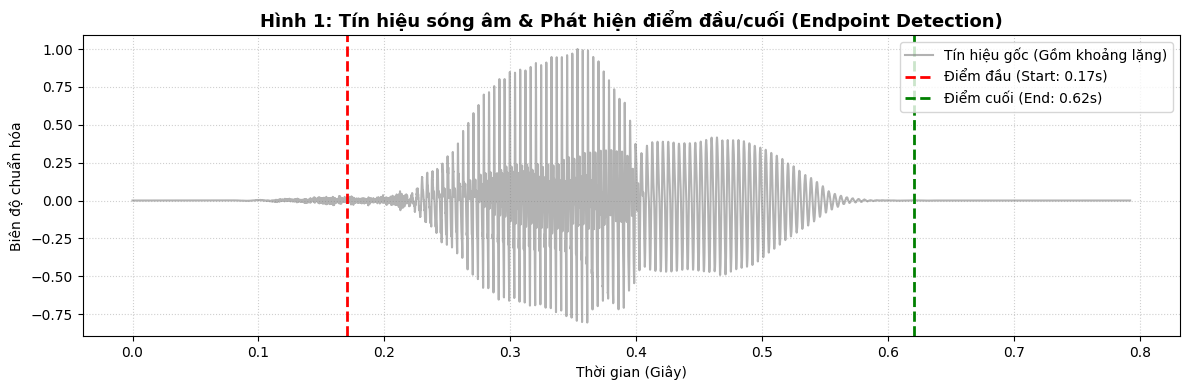

In [16]:
import matplotlib.pyplot as plt
def load_audio(path):
    """Đọc file WAV và chuẩn hóa biên độ [-1, 1]"""
    y, _ = librosa.load(path, sr=FS, mono=True)
    y = y / (np.max(np.abs(y)) + 1e-9)
    return y

def trim_energy(y, top_db=25, margin_ms=50):
    """Endpoint Detection: Cắt bỏ khoảng lặng đầu và cuối file"""
    yt, idx = librosa.effects.trim(y, top_db=top_db, frame_length=WIN, hop_length=HOP)
    m = int(FS * margin_ms / 1000)
    s = max(0, idx[0] - m)
    e = min(len(y), idx[1] + m)
    return y[s:e], (s, e)

# --- VẼ HÌNH 1: MINH HỌA ENDPOINT DETECTION ---
sample_file = DATASET_DIR / "khong" / "khong_01.wav"
y_sample = load_audio(sample_file)
y_trim, (start_idx, end_idx) = trim_energy(y_sample)

time_full = np.arange(len(y_sample)) / FS
start_time = start_idx / FS
end_time = end_idx / FS

plt.figure(figsize=(12, 4))
plt.plot(time_full, y_sample, color='gray', alpha=0.6, label='Tín hiệu gốc (Gồm khoảng lặng)')
plt.axvline(x=start_time, color='red', linestyle='--', linewidth=2, label=f'Điểm đầu (Start: {start_time:.2f}s)')
plt.axvline(x=end_time, color='green', linestyle='--', linewidth=2, label=f'Điểm cuối (End: {end_time:.2f}s)')
plt.title("Hình 1: Tín hiệu sóng âm & Phát hiện điểm đầu/cuối (Endpoint Detection)", fontsize=13, fontweight='bold')
plt.xlabel("Thời gian (Giây)")
plt.ylabel("Biên độ chuẩn hóa")
plt.legend(loc='upper right')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.savefig("hinh1_endpoint_detection.png", dpi=300)
plt.show()


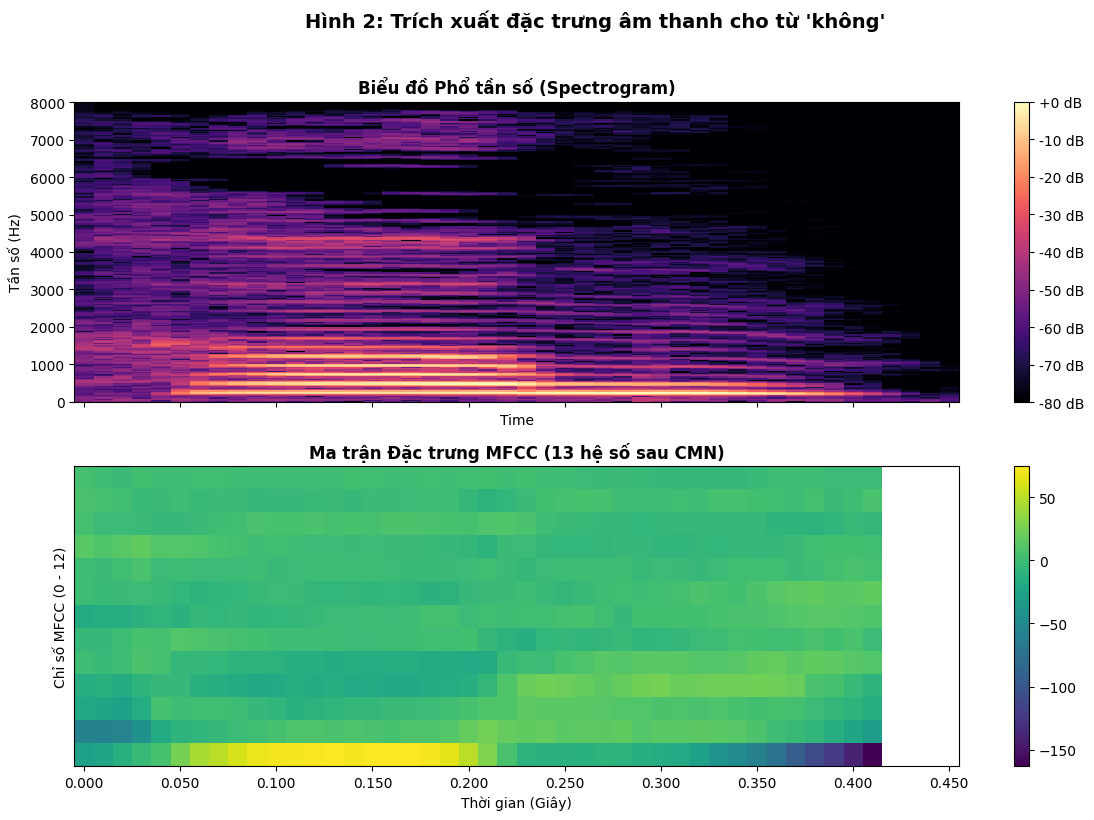

In [17]:
def mfcc_feature(y):
    """
    Quy trình trích xuất đặc trưng:
    1. Pre-emphasis (Tiền nhấn)
    2. Framing & Cửa sổ Hamming
    3. Tính 13 hệ số MFCC qua ngân hàng lọc Mel
    4. Cepstral Mean Normalization (CMN)
    """
    # 1. Pre-emphasis filter
    y_emp = lfilter([1.0, -PRE_EMPH], [1.0], y)
    
    # 2. MFCC Extraction
    M = librosa.feature.mfcc(
        y=y_emp, sr=FS, n_mfcc=N_MFCC, n_mels=N_MELS,
        n_fft=N_FFT, win_length=WIN, hop_length=HOP,
        window='hamming', center=False
    )
    
    # 3. Cepstral Mean Normalization (CMN)
    M = M - np.mean(M, axis=1, keepdims=True)
    return M.T  # Ma trận (T_frames, 13)

# --- VẼ HÌNH 2: MINH HỌA SPECTROGRAM & MFCC HEATMAP ---
D_spec = librosa.amplitude_to_db(np.abs(librosa.stft(y_trim, n_fft=N_FFT, hop_length=HOP)), ref=np.max)
mfcc_matrix = mfcc_feature(y_trim).T  # Ma trận (13, T_frames)

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Biểu đồ Phổ tần số (Spectrogram)
img1 = librosa.display.specshow(D_spec, sr=FS, hop_length=HOP, x_axis='time', y_axis='linear', ax=axes[0], cmap='magma')
axes[0].set_title("Biểu đồ Phổ tần số (Spectrogram)", fontsize=12, fontweight='bold')
axes[0].set_ylabel("Tần số (Hz)")
fig.colorbar(img1, ax=axes[0], format="%+2.0f dB")

# Biểu đồ Ma trận đặc trưng MFCC
img2 = librosa.display.specshow(mfcc_matrix, sr=FS, hop_length=HOP, x_axis='time', ax=axes[1], cmap='viridis')
axes[1].set_title("Ma trận Đặc trưng MFCC (13 hệ số sau CMN)", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Thời gian (Giây)")
axes[1].set_ylabel("Chỉ số MFCC (0 - 12)")
fig.colorbar(img2, ax=axes[1])

plt.suptitle("Hình 2: Trích xuất đặc trưng âm thanh cho từ 'không'", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("hinh2_spectrogram_mfcc.png", dpi=300)
plt.show()

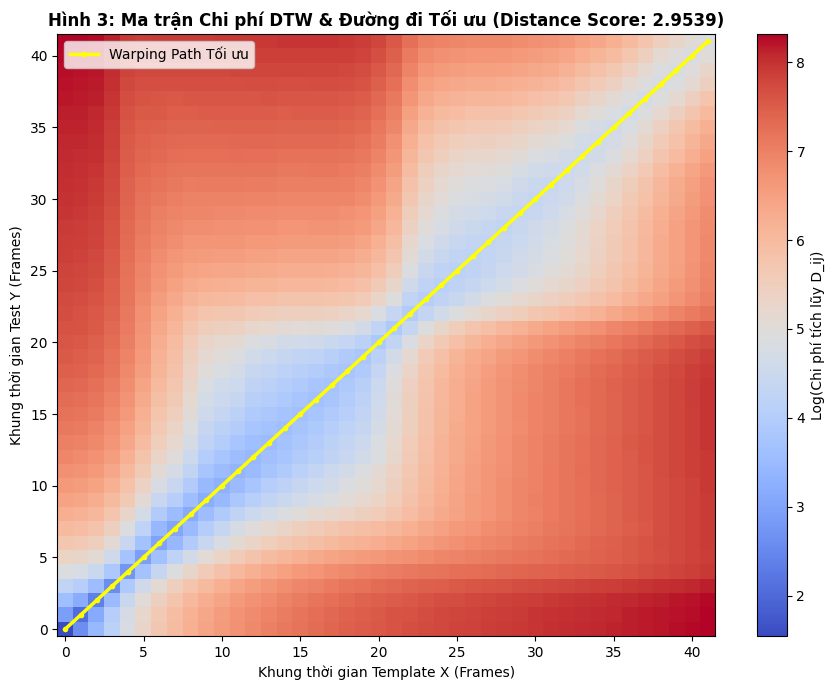

In [18]:
def dtw_distance(X, Y):
    """
    Tính khoảng cách DTW giữa 2 chuỗi đặc trưng MFCC: X (N, 13) và Y (M, 13)
    Trả về: (Khoảng cách chuẩn hóa, Đường đi tối ưu, Ma trận chi phí tích lũy)
    """
    N, M = len(X), len(Y)
    D = np.full((N + 1, M + 1), np.inf)
    D[0, 0] = 0.0
    back = np.zeros((N + 1, M + 1, 2), dtype=int)
    
    # Lập bảng quy hoạch động
    for i in range(1, N + 1):
        for j in range(1, M + 1):
            local_dist = np.linalg.norm(X[i - 1] - Y[j - 1])
            choices = [
                (D[i - 1, j], i - 1, j),        # Kéo giãn
                (D[i, j - 1], i, j - 1),        # Co nén
                (D[i - 1, j - 1], i - 1, j - 1)   # Đồng bộ
            ]
            best, pi, pj = min(choices, key=lambda z: z[0])
            D[i, j] = local_dist + best
            back[i, j] = (pi, pj)
            
    # Truy vết đường đi tối ưu (Backtracking)
    path = []
    i, j = N, M
    while i > 0 or j > 0:
        path.append((i - 1, j - 1))
        i, j = back[i, j]
    path.reverse()
    
    norm_cost = D[N, M] / max(len(path), 1)
    return norm_cost, path, D[1:, 1:]

# --- VẼ HÌNH 3: MINH HỌA MA TRẬN CHI PHÍ DTW & WARPING PATH ---
file_ref = DATASET_DIR / "khong" / "khong_01.wav"
file_test = DATASET_DIR / "khong" / "khong_02.wav"

X_ref = mfcc_feature(trim_energy(load_audio(file_ref))[0])
Y_test = mfcc_feature(trim_energy(load_audio(file_test))[0])

dtw_cost, dtw_path, D_matrix = dtw_distance(X_ref, Y_test)

path_x = [p[0] for p in dtw_path]
path_y = [p[1] for p in dtw_path]

plt.figure(figsize=(9, 7))
plt.imshow(np.log1p(D_matrix.T), origin='lower', cmap='coolwarm', aspect='auto')
plt.plot(path_x, path_y, color='yellow', linewidth=2.5, marker='o', markersize=3, label='Warping Path Tối ưu')

plt.title(f"Hình 3: Ma trận Chi phí DTW & Đường đi Tối ưu (Distance Score: {dtw_cost:.4f})", fontsize=12, fontweight='bold')
plt.xlabel("Khung thời gian Template X (Frames)")
plt.ylabel("Khung thời gian Test Y (Frames)")
plt.colorbar(label='Log(Chi phí tích lũy D_ij)')
plt.legend(loc='upper left')
plt.tight_layout()
plt.savefig("hinh3_dtw_warping_path.png", dpi=300)
plt.show()

--- ĐÁNH GIÁ MÔ HÌNH TRÊN TẬP TEST (FILE .04 & .05) ---
File Test          | Nhãn Thật  | Dự Đoán    | Top-1 DTW Score
--------------------------------------------------------------
khong_04.wav       | khong      | khong      | 0.0000         
khong_05.wav       | khong      | khong      | 0.0000         
mot_04.wav         | mot        | mot        | 0.0000         
mot_05.wav         | mot        | mot        | 0.0000         
hai_04.wav         | hai        | hai        | 0.0000         
hai_05.wav         | hai        | hai        | 0.0000         
ba_04.wav          | ba         | ba         | 0.0000         
ba_05.wav          | ba         | ba         | 2.3947         
bon_04.wav         | bon        | bon        | 0.0000         
bon_05.wav         | bon        | bon        | 1.1911         

KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH (ACCURACY): 100.00%


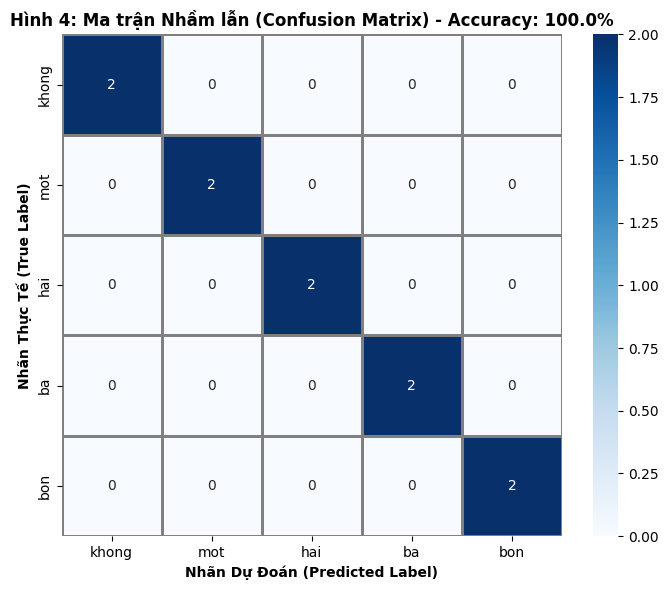

✓ Đã xuất bảng kết quả chi tiết ra file 'results.csv' thành công!


In [21]:
print("--- ĐÁNH GIÁ MÔ HÌNH TRÊN TẬP TEST (FILE .04 & .05) ---")

y_true, y_pred = [], []
results_data = []

print(f"{'File Test':<18} | {'Nhãn Thật':<10} | {'Dự Đoán':<10} | {'Top-1 DTW Score':<15}")
print("-" * 62)

for lab in LABELS:
    test_files = sorted((Path(DATASET_DIR) / lab).glob('*.wav'))[3:]
    for f in test_files:
        pred, scores = recognize(f, templates)
        top1_score = list(scores.values())[0]
        
        y_true.append(lab)
        y_pred.append(pred)
        
        results_data.append({
            "File Test": f.name,
            "Nhãn Thật": lab,
            "Nhãn Dự Đoán": pred,
            "Top-1 Score": round(top1_score, 4)
        })
        print(f"{f.name:<18} | {lab:<10} | {pred:<10} | {top1_score:<15.4f}")

# Tính toán Accuracy và Confusion Matrix
acc = accuracy_score(y_true, y_pred)
cm = confusion_matrix(y_true, y_pred, labels=LABELS)

print("\n" + "=" * 45)
print(f"KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH (ACCURACY): {acc * 100:.2f}%")
print("=" * 45)

# --- VẼ HÌNH 4: MA TRẬN NHẦM LẪN (CONFUSION MATRIX HEATMAP) ---
plt.figure(figsize=(7, 6))
sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Blues', 
    xticklabels=LABELS, 
    yticklabels=LABELS,
    cbar=True,
    linewidths=1,
    linecolor='gray'
)

plt.title(f"Hình 4: Ma trận Nhầm lẫn (Confusion Matrix) - Accuracy: {acc*100:.1f}%", fontsize=12, fontweight='bold')
plt.xlabel("Nhãn Dự Đoán (Predicted Label)", fontweight='bold')
plt.ylabel("Nhãn Thực Tế (True Label)", fontweight='bold')
plt.tight_layout()
plt.savefig("hinh4_confusion_matrix.png", dpi=300)
plt.show()

# Xuất báo cáo CSV
pd.DataFrame(results_data).to_csv("results.csv", index=False)
print("✓ Đã xuất bảng kết quả chi tiết ra file 'results.csv' thành công!")